# Queda Livre: Modelagem Matemática e Implementação Computacional

Este notebook segue o roteiro proposto para o trabalho prático de modelagem matemática da Queda Livre, unindo teoria, programação e análise de resultados. Cada etapa é explicada em detalhes, com células Markdown e código Python, além de salvar os dados e gráficos gerados.

## Passo 1: Implementação Básica do Modelo de Queda Livre

Neste passo, vamos implementar o modelo discreto da queda livre usando o método de Euler. O objetivo é calcular, passo a passo, a posição e a velocidade de uma pedra até ela atingir o solo.

### Entradas do Modelo

- **Altura inicial** $H$ (ex: 100 m)
- **Velocidade inicial** $V$ (ex: 0 m/s)
- **Gravidade** $g$ (9,81 m/s²)
- **Passo de tempo** $\Delta t$ (ex: 0,1 s)

> **Observação:** Todos os dados de entrada e saída serão salvos em arquivos `.txt` na pasta `src/dados` e os gráficos gerados em `.png` na pasta `src/graficos`. Isso facilita a organização e reutilização dos resultados.


In [107]:
# Criação das pastas para dados e gráficos (executar uma vez)
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
# Caminho absoluto da pasta onde está o notebook (compatível com Jupyter)
base_dir = Path().resolve()
dados_dir = base_dir / 'dados'
graficos_dir = base_dir / 'graficos'
dados_dir.mkdir(exist_ok=True)
graficos_dir.mkdir(exist_ok=True)
print(f'Pastas criadas ou já existentes:\n{dados_dir}\n{graficos_dir}')


Pastas criadas ou já existentes:
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\pratica01\src\dados
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\pratica01\src\graficos


In [108]:
# Função para simular a queda livre usando o método de Euler
def simula_queda_livre(H, V, g, dt):
    t = [0.0]
    x = [H]
    v = [V]
    while x[-1] > 0:
        t.append(t[-1] + dt)
        x.append(x[-1] + v[-1]*dt)
        v.append(v[-1] - g*dt)
    if x[-1] < 0:
        x[-1] = 0
    return t, x, v




In [109]:
# Definindo os parâmetros iniciais
H = 100.0 # altura inicial (m)
V = 0.0   # velocidade inicial (m/s)
g = 9.81  # gravidade (m/s^2)

dt = 0.1  # passo de tempo (s)
dt_list = [1.0, 0.5, 0.1, 0.01]  # lista de passos de tempo

# Salvando dados de entrada
dados_entrada = f'H = {H} m\nV = {V} m/s\ng = {g} m/s^2\ndt = {dt} s\ndt_list = {dt_list}\n'
with open(os.path.join(dados_dir, 'entrada_queda_livre.txt'), 'w') as f:
    f.write(dados_entrada)

# Chamada da função de simulação para o dt principal
t, x, v = simula_queda_livre(H, V, g, dt)


In [110]:
# Salvando os dados de saída em txt
saida_txt = os.path.join(dados_dir, 'saida_queda_livre.txt')
with open(saida_txt, 'w') as f:
    f.write('tempo(s)\tposicao(m)\tvelocidade(m/s)\n')
    for ti, xi, vi in zip(t, x, v):
        f.write(f'{ti:.4f}\t{xi:.4f}\t{vi:.4f}\n')


## Passo 2: Gráficos do Modelo de Queda Livre

A seguir, vamos gerar os três gráficos obrigatórios: posição x tempo, velocidade x tempo e aceleração x tempo. Todos os gráficos serão salvos na pasta `src/saida`.

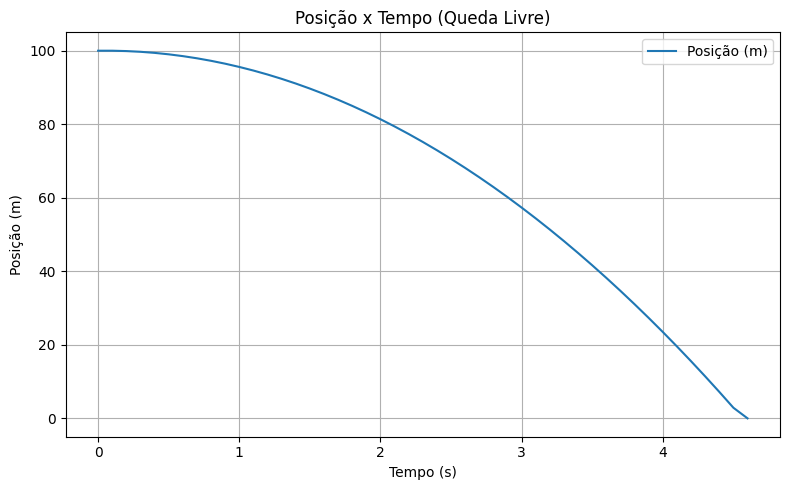

In [111]:
# Gráfico 1: Posição x Tempo
plt.figure(figsize=(8,5))
plt.plot(t, x, label='Posição (m)')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição (m)')
plt.title('Posição x Tempo (Queda Livre)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(graficos_dir, 'grafico_posicao_tempo.png'))
plt.show()


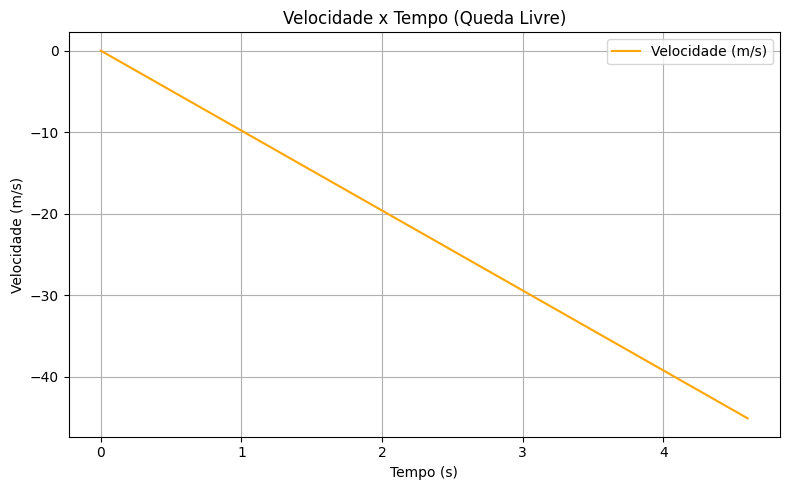

In [112]:
# Gráfico 2: Velocidade x Tempo
plt.figure(figsize=(8,5))
plt.plot(t, v, label='Velocidade (m/s)', color='orange')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade (m/s)')
plt.title('Velocidade x Tempo (Queda Livre)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(graficos_dir, 'grafico_velocidade_tempo.png'))
plt.show()


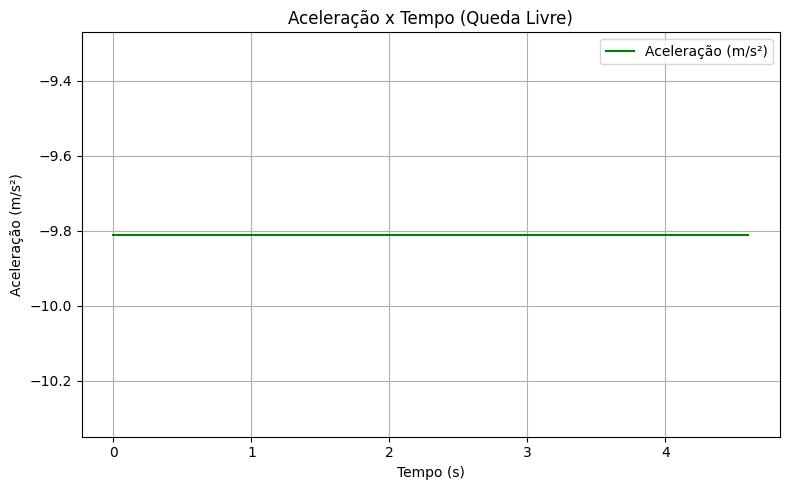

In [113]:
# Gráfico 3: Aceleração x Tempo (constante)
aceleracao = [-g for _ in t]
plt.figure(figsize=(8,5))
plt.plot(t, aceleracao, label='Aceleração (m/s²)', color='green')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração (m/s²)')
plt.title('Aceleração x Tempo (Queda Livre)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(graficos_dir, 'grafico_aceleracao_tempo.png'))
plt.show()


## Passo 3: Discussão - Partícula vs. Corpo Rígido

No modelo básico de queda livre, consideramos a pedra como uma **partícula**: um ponto sem dimensões, apenas com massa. Isso simplifica os cálculos, pois não há rotação nem resistência do ar. Se considerássemos um **corpo rígido**, o objeto teria tamanho, formato e poderia girar durante a queda, além de sofrer influência da aerodinâmica (resistência do ar). Isso tornaria o modelo mais complexo e realista, levando à necessidade de incluir forças adicionais e equações para rotação e arrasto.

## Passo 4: Resistência do Ar (Bônus)

Agora, vamos refinar o modelo incluindo a resistência do ar proporcional à velocidade. O coeficiente de arrasto $c$ será escolhido para ilustrar o efeito.

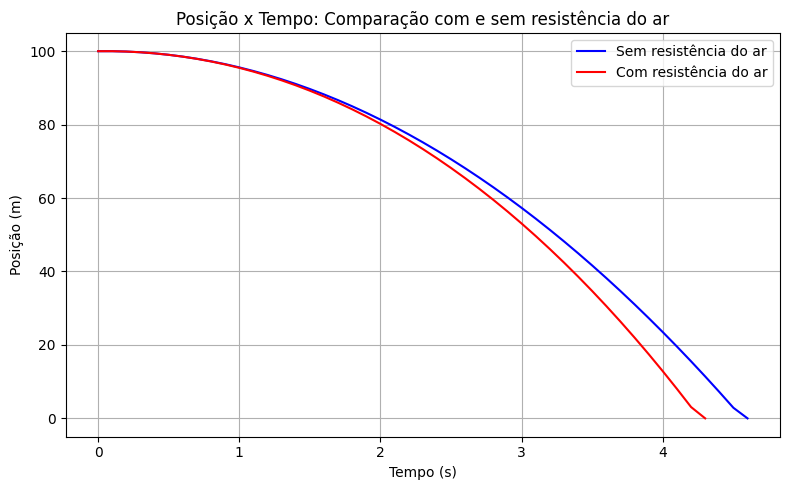

In [114]:
# Parâmetros para resistência do ar
c = 0.1  # coeficiente de arrasto (ajustável)

# Inicialização
tr = [0.0]
xr = [H]
vr = [V]

# Loop com resistência do ar
while xr[-1] > 0:
    tr.append(tr[-1] + dt)
    xr.append(xr[-1] + vr[-1]*dt)
    vr.append(vr[-1] - g*dt + c*vr[-1]*dt)

if xr[-1] < 0:
    xr[-1] = 0

# Salvando saída
with open(dados_dir / 'saida_queda_livre_resistencia.txt', 'w') as f:
    f.write('tempo(s)\tposicao(m)\tvelocidade(m/s)\n')
    for ti, xi, vi in zip(tr, xr, vr):
        f.write(f'{ti:.4f}\t{xi:.4f}\t{vi:.4f}\n')

# Gráfico de comparação posição x tempo (com e sem resistência)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(t, x, label='Sem resistência do ar', color='blue')
plt.plot(tr, xr, label='Com resistência do ar', color='red')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição (m)')
plt.title('Posição x Tempo: Comparação com e sem resistência do ar')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(graficos_dir / 'grafico_posicao_comparacao_resistencia.png')
plt.show()


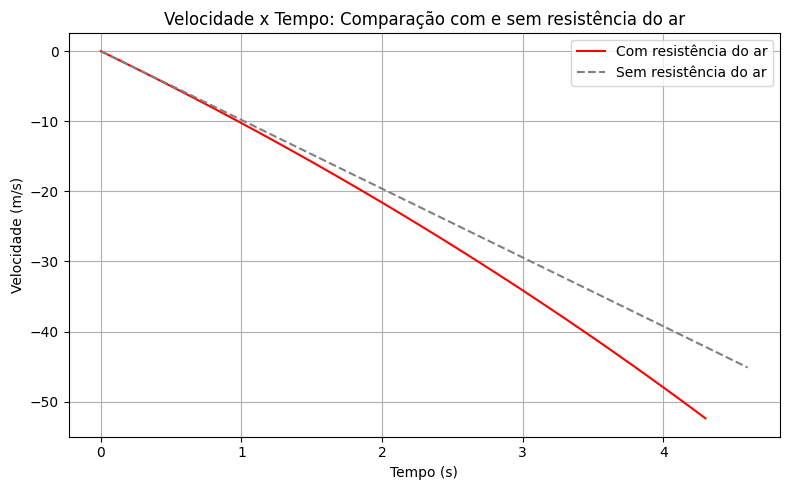

In [115]:
# Gráfico: Comparação da velocidade com e sem resistência do ar
plt.figure(figsize=(8,5))
plt.plot(tr, vr, label='Com resistência do ar', color='red')
plt.plot(t, v, '--', label='Sem resistência do ar', color='gray')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade (m/s)')
plt.title('Velocidade x Tempo: Comparação com e sem resistência do ar')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(graficos_dir / 'grafico_velocidade_comparacao_resistencia.png')
plt.show()


## Passo 5: Acurácia vs. Tamanho do Passo de Tempo $\Delta t$ (Bônus)

Vamos comparar o tempo de queda calculado pelo modelo para diferentes valores de $\Delta t$ e comparar com o valor analítico exato.

In [116]:
# Função para simular queda livre com passo dt
def simula_queda(dt, H=100.0, V=0.0, g=9.81):
    t = [0.0]
    x = [H]
    v = [V]
    while x[-1] > 0:
        t.append(t[-1] + dt)
        x.append(x[-1] + v[-1]*dt)
        v.append(v[-1] - g*dt)
    if x[-1] < 0:
        x[-1] = 0
    return t, x, v

tempo_queda = []
for dt_test in dt_list:
    t_sim, x_sim, v_sim = simula_queda(dt_test, H, V, g)
    tempo_queda.append(t_sim[-1])
    # Salvar cada simulação com cabeçalho padrão
    with open(os.path.join(dados_dir, f'saida_queda_livre_dt_{str(dt_test).replace(".","_")}.txt'), 'w') as f:
        f.write('tempo(s)\tposicao(m)\tvelocidade(m/s)\n')
        for ti, xi, vi in zip(t_sim, x_sim, v_sim):
            f.write(f'{ti:.4f}\t{xi:.4f}\t{vi:.4f}\n')

t_analitico = np.sqrt(2*H/g)
tempos = tempo_queda + [t_analitico]
labels = [f'dt={dt}s' for dt in dt_list] + ['Analítico']
for l, t_ in zip(labels, tempos):
    print(f'{l}: {t_:.4f} s')


dt=1.0s: 6.0000 s
dt=0.5s: 5.0000 s
dt=0.1s: 4.6000 s
dt=0.01s: 4.5300 s
Analítico: 4.5152 s


### Conclusão

Quanto menor o passo de tempo $\Delta t$, mais próximo o resultado do modelo computacional chega do valor analítico exato. Passos grandes aumentam o erro, mostrando a importância de escolher um $\Delta t$ adequado para garantir precisão.

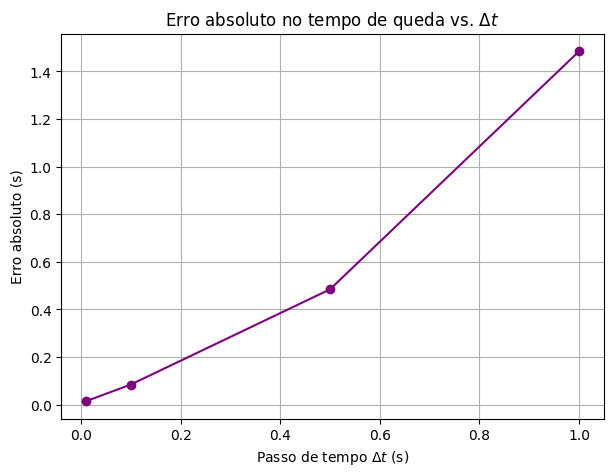

In [117]:
# Cálculo e salvamento da acurácia (erro absoluto)
erros = [abs(t_simulado - t_analitico) for t_simulado in tempo_queda]

# Salvar erros em txt com cabeçalho padrão
with open(os.path.join(dados_dir, 'acuracia_queda_livre.txt'), 'w') as f:
    f.write('dt(s)\ttempo_simulado(s)\ttempo_analitico(s)\terro_absoluto(s)\n')
    for dt_val, t_sim, erro in zip(dt_list, tempo_queda, erros):
        f.write(f'{dt_val}\t{t_sim:.6f}\t{t_analitico:.6f}\t{erro:.6f}\n')

# Gráfico do erro absoluto vs dt
plt.figure(figsize=(7,5))
plt.plot(dt_list, erros, marker='o', linestyle='-', color='purple')
plt.xlabel(r'Passo de tempo $\Delta t$ (s)')
plt.ylabel(r'Erro absoluto (s)')
plt.title(r'Erro absoluto no tempo de queda vs. $\Delta t$')
plt.grid(True)
plt.savefig(os.path.join(graficos_dir, 'grafico_erro_absoluto_vs_dt.png'))
plt.show()


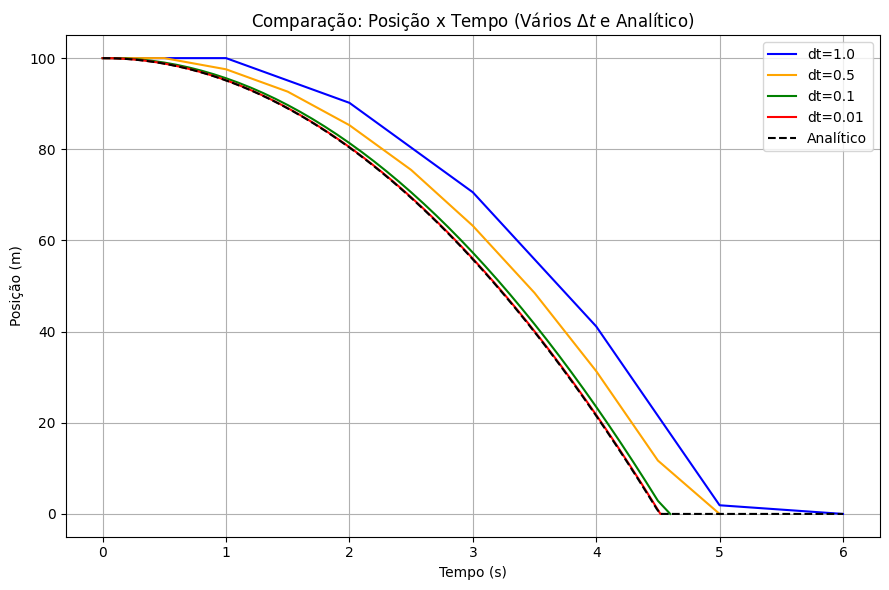

In [118]:
# Gráfico final: Comparação dos resultados de posição x tempo para diferentes $\Delta t$ e solução analítica
cores = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']
plt.figure(figsize=(9,6))
for i, dt_test in enumerate(dt_list):
    t_sim, x_sim, _ = simula_queda(dt_test)
    plt.plot(t_sim, x_sim, label=f'dt={dt_test}', color=cores[i])
# Solução analítica para a posição: x(t) = H - 0.5*g*t^2
import numpy as np
t_max = max([simula_queda(dt)[0][-1] for dt in dt_list])
t_analit = np.linspace(0, t_max, 200)
x_analit = H - 0.5 * g * t_analit**2
x_analit[x_analit < 0] = 0
plt.plot(t_analit, x_analit, '--', label='Analítico', color='black')
plt.xlabel(r'Tempo (s)')
plt.ylabel(r'Posição (m)')
plt.title(r'Comparação: Posição x Tempo (Vários $\Delta t$ e Analítico)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(graficos_dir, 'grafico_comparacao_posicao_tempo.png'))
plt.show()
